# 8 · PDHG for a conic program

A huge family of problems are **conic programs**:

$$ \min_x \; c^\top x \quad\text{subject to}\quad A x = b,\;\; x \in \mathcal{K}, $$

where $\mathcal{K}$ is a convex cone — the nonnegative orthant (LP), the second-order cone
(SOCP), or the PSD cone (SDP). The **Primal–Dual Hybrid Gradient** method (PDHG /
Chambolle–Pock) solves these with three ingredients, each of which SpaceCore provides directly:

* a linear operator $A$ and its **adjoint** — a `LinOp`;
* a **projection onto the cone** $\mathcal{K}$ — for the orthant, the cone of squares of a
  Jordan-algebra space, projected with `spectral_apply`;
* a dual update for the equality constraint.

We solve a tiny standard-form LP whose optimum we know, and watch PDHG walk a primal path
across the probability simplex to the answer.

**You will learn to** assemble a saddle-point solver from a SpaceCore operator and a cone
projection, with no dense KKT system.

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import spacecore as sc

# A clean, consistent palette + style for every figure in the tutorials.
BLUE, INDIGO, CYAN = "#2563eb", "#4f46e5", "#0891b2"
PINK, AMBER, GREEN = "#db2777", "#d97706", "#059669"
SLATE, GRID = "#334155", "#e5e9f0"

mpl.rcParams.update({
    "figure.figsize": (7.2, 4.2), "figure.dpi": 120, "savefig.dpi": 120,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": SLATE, "axes.linewidth": 1.0,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 1.0,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": SLATE,
    "axes.labelcolor": SLATE, "axes.labelsize": 11,
    "xtick.color": SLATE, "ytick.color": SLATE,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "font.size": 11,
    "legend.frameon": False, "legend.fontsize": 10,
    "lines.linewidth": 2.4, "lines.markersize": 6, "image.cmap": "magma",
})
mpl.rcParams["axes.prop_cycle"] = mpl.cycler(
    color=[BLUE, PINK, GREEN, AMBER, INDIGO, CYAN])

print("spacecore", sc.__version__, "| numpy", np.__version__)

spacecore 0.4.0 | numpy 2.4.2


In [2]:
ctx = sc.Context(sc.NumpyOps(), dtype=np.float64)
ops = ctx.ops

## 1 · The problem and the cone

$$ \min \; c^\top x \;\;\text{s.t.}\;\; \mathbf{1}^\top x = 1,\;\; x \ge 0,
   \qquad c = (2, 1, 3). $$

The feasible set is the probability simplex; since the objective is linear, the optimum is the
cheapest vertex — here $x^\star = (0,1,0)$ with value $1$.

The cone $\mathcal{K} = \mathbb{R}^3_{\ge 0}$ is the **cone of squares** of an
`ElementwiseJordanSpace`. Projection onto it is $\max(\cdot, 0)$, expressed through the Jordan
spectral calculus.

In [3]:
A_mat = np.array([[1.0, 1.0, 1.0]])
b     = ctx.asarray([1.0])
c     = ctx.asarray([2.0, 1.0, 3.0])

X = sc.ElementwiseJordanSpace((3,), ctx)     # primal lives in the nonnegative orthant
Y = sc.DenseVectorSpace((1,), ctx)           # multiplier for the equality constraint
A = sc.DenseLinOp(ctx.asarray(A_mat), X, Y, ctx)

# Projection onto K = {x >= 0}, via the Jordan spectral map  s -> max(s, 0)
proj_K = lambda x: X.spectral_apply(x, lambda s: ops.maximum(s, 0.0))

demo = ctx.asarray([0.7, -0.4, 0.2])
print("project (0.7, -0.4, 0.2) onto the orthant:", proj_K(demo))

project (0.7, -0.4, 0.2) onto the orthant: [0.7 0.  0.2]


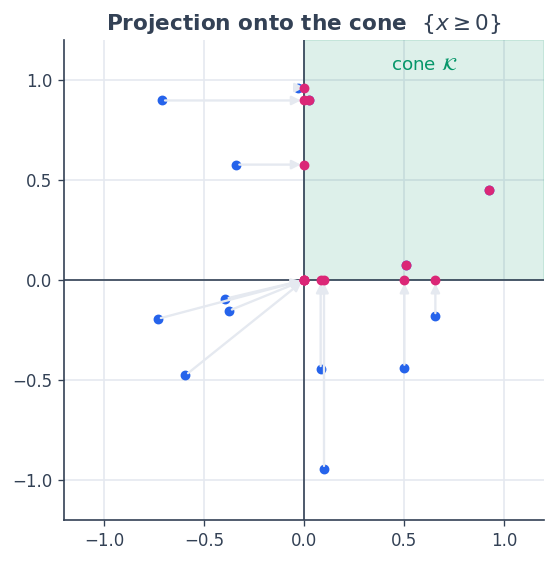

In [4]:
# a picture of the cone projection in 2D
rng = np.random.default_rng(1)
E2 = sc.ElementwiseJordanSpace((2,), ctx)
pj2 = lambda v: E2.spectral_apply(v, lambda s: ops.maximum(s, 0.0))
pts = rng.uniform(-1, 1, size=(14, 2))

fig, ax = plt.subplots(figsize=(5.2, 5.2))
ax.axhspan(0, 1.2, xmin=0.5, color=GREEN, alpha=0.06)
ax.fill([0, 1.2, 1.2, 0], [0, 0, 1.2, 1.2], color=GREEN, alpha=0.08)
for p in pts:
    q = np.asarray(pj2(ctx.asarray(p)))
    ax.annotate("", xy=q, xytext=p, arrowprops=dict(arrowstyle="-|>", color=GRID, lw=1.4))
    ax.scatter(*p, color=BLUE, s=24); ax.scatter(*q, color=PINK, s=24, zorder=5)
ax.axhline(0, color=SLATE, lw=1); ax.axvline(0, color=SLATE, lw=1)
ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.2, 1.2); ax.set_aspect("equal")
ax.set_title("Projection onto the cone  $\\{x \\geq 0\\}$")
ax.text(0.6, 1.05, "cone $\\mathcal{K}$", color=GREEN, fontsize=11, ha="center")
plt.show()

## 2 · The PDHG iteration

PDHG alternates a **primal** step (gradient in $c + A^\top y$, then project onto $\mathcal{K}$),
an over-relaxation, and a **dual** step (drive $Ax \to b$). The operator's adjoint `A.rapply`
supplies $A^\top y$; the cone projection is the primal proximal step.

In [5]:
L = float(np.linalg.norm(A_mat, 2))     # operator norm of A
tau = sigma = 0.9 / L                     # step sizes:  tau*sigma*L^2 < 1

x = ctx.asarray(np.full(3, 1/3))          # start at the simplex centroid
y = Y.zeros()
x_star = np.array([0.0, 1.0, 0.0])

traj, obj_gap, feas = [np.asarray(x).copy()], [], []
for k in range(8000):
    x_prev = x
    x = proj_K(x - tau * (c + A.rapply(y)))          # primal: step + cone projection
    x_bar = 2.0 * x - x_prev                          # over-relaxation
    y = y + sigma * (A.apply(x_bar) - b)              # dual: enforce Ax = b
    obj_gap.append(abs(float(ops.vdot(c, x)) - 1.0))
    feas.append(float(Y.norm(A.apply(x) - b)))
    if k % 40 == 0:
        traj.append(np.asarray(x).copy())
traj = np.array(traj)

print("PDHG solution x :", np.round(np.asarray(x), 6))
print("objective cᵀx   :", float(ops.vdot(c, x)), " (optimum = 1.0)")
print("feasibility ‖Ax−b‖:", feas[-1])
print("x ≥ 0 ?          :", bool(np.all(np.asarray(x) >= -1e-12)))

PDHG solution x : [0. 1. 0.]
objective cᵀx   : 0.9999999999999999  (optimum = 1.0)
feasibility ‖Ax−b‖: 1.1102230246251565e-16
x ≥ 0 ?          : True


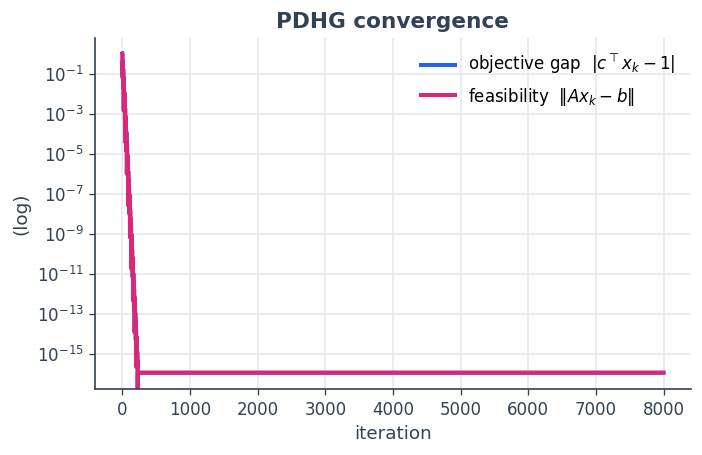

In [6]:
fig, ax = plt.subplots(figsize=(6.4, 3.8))
ax.semilogy(obj_gap, color=BLUE, label="objective gap  $|c^\\top x_k - 1|$")
ax.semilogy(feas, color=PINK, label="feasibility  $\\|Ax_k - b\\|$")
ax.set_title("PDHG convergence"); ax.set_xlabel("iteration"); ax.set_ylabel("(log)")
ax.legend(); plt.show()

## 3 · The path across the simplex

Mapping each iterate to barycentric coordinates, we see PDHG start at the centroid and head to
the cheap vertex $x^\star=(0,1,0)$. The background shades the linear objective $c^\top x$ — its
straight level sets confirm the optimum must sit at a corner.

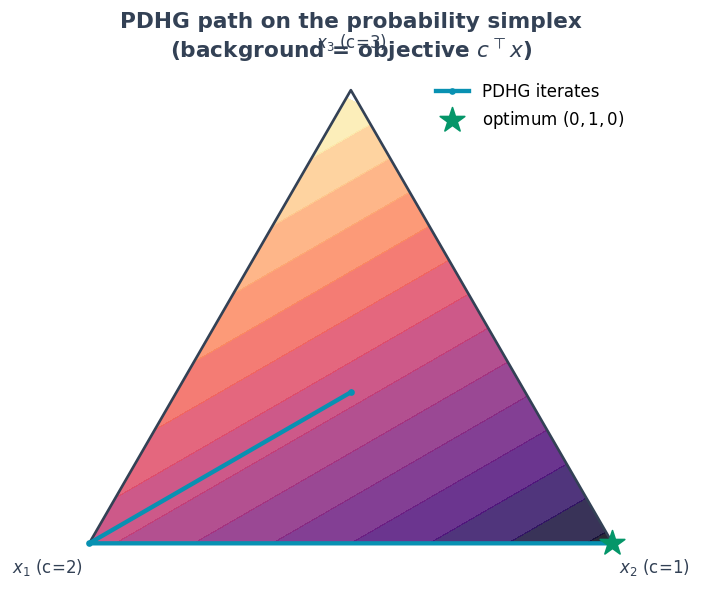

In [7]:
import matplotlib.tri as mtri
corners = np.array([[0.0, 0.0], [1.0, 0.0], [0.5, np.sqrt(3)/2]])   # triangle in 2D
def bary(x):                                                        # simplex → 2D
    x = np.asarray(x); return x @ corners

# shade the objective over the simplex interior
s = rng.dirichlet(np.ones(3), size=4000)
pts2d = s @ corners
vals = s @ np.asarray(c)

fig, ax = plt.subplots(figsize=(6.2, 5.6))
tri = mtri.Triangulation(pts2d[:, 0], pts2d[:, 1])
ax.tricontourf(tri, vals, levels=18, cmap="magma", alpha=0.85)
ax.plot(*np.vstack([corners, corners[0]]).T, color=SLATE, lw=1.6)

P = bary(traj)
ax.plot(P[:, 0], P[:, 1], color=CYAN, lw=2.6, marker="o", ms=3, label="PDHG iterates")
ax.scatter(*bary(x_star), color=GREEN, s=240, marker="*", zorder=6, label="optimum $(0,1,0)$")
labels = ["$x_1$ (c=2)", "$x_2$ (c=1)", "$x_3$ (c=3)"]
for corner, lab in zip(corners, labels):
    off = (corner - corners.mean(0)) * 0.16
    ax.text(*(corner + off), lab, ha="center", va="center", fontsize=10, color=SLATE)
ax.set_aspect("equal"); ax.axis("off"); ax.legend(loc="upper right")
ax.set_title("PDHG path on the probability simplex\n(background = objective $c^\\top x$)")
plt.show()

The iterates slide down the objective gradient and park at the $x_2$ corner — the vertex
with the smallest cost coefficient — exactly the LP optimum.

> **Other cones, same loop.** Only the projection changes. For the second-order cone use the
> Lorentz projection; for the PSD cone use `sc.HermitianSpace(n).psd_proj`, which clips the
> eigenvalues at zero. The operator $A$, the adjoint `A.rapply`, and the PDHG skeleton stay
> identical — which is the point of phrasing the whole thing in terms of spaces and operators.

## Recap

* A **conic program** needs a linear operator, its adjoint, and a cone projection — PDHG glues
  them into a primal–dual saddle-point solver.
* SpaceCore supplies $A$ and `A.rapply` as a `LinOp`, and the **orthant projection** as the
  Jordan spectral map $\max(\cdot,0)$ on an `ElementwiseJordanSpace`.
* Swapping the cone (SOC, PSD) swaps only the projection; the operator algebra is untouched.

That closes the tutorial path: from [contexts](01_backend_and_context.ipynb) and
[spaces](02_linear_algebra.ipynb), through [functionals](03_functionals.ipynb) and
[structure](04_tree_spaces.ipynb), to four worked examples — a
[Tikhonov inverse problem](05_weighted_tikhonov.ipynb),
[optimal transport](06_optimal_transport.ipynb),
[manifold descent](07_manifold_descent.ipynb), and conic optimisation — all built from the
same handful of typed objects.